<a href="https://colab.research.google.com/github/limco-unipisa/lezioni-julia/blob/main/08-ODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Laboratorio di Introduzione alla Matematica Computazionale - Esercizi in Julia**  
## **Esercitazione 8: equazioni differenziali ordinarie**

L'obiettivo di questa sezione è acquisire familiarità con la soluzione di equazioni differenziali ordinarie in Julia.



---
# 1. Introduzione

Ci proponiamo di risolvere numericamente un problema di Cauchy del tipo
$$
\left\{
\begin{array}{l}
x'(t)=f(x(t),t),\qquad t\in [a,b]\\
x(a)=c
\end{array}\right.
$$
dove $f(x,t):\mathbb{R}^m\times\mathbb{R}\rightarrow\mathbb{R}^m$ e' una funzione assegnata opportununamente regolare e $c\in\mathbb{R}^m$ e' un vettore dato. Supporremo che la soluzione esista e sia unica.

Esistono numerosi metodi numerici per la soluzione di problemi ai valori iniziali, che risultano piu' o meno efficaci a seconda del tipo di problema, dei parametri usati, del condizionamento... In generale, comunque, i metodi numerici si basano su una discretizzazione dell'intervallo di integrazione e della soluzione, che quindi sono entrambi rappresentati come vettori.

Per esempio, il piu' semplice di questi metodi, noto come *metodo di Eulero esplicito*, approssima la funzione $x(t):\mathbb{R}\rightarrow \mathbb{R}$ per mezzo dei suoi valori $y_i$ nei nodi $t_i=a+ih$, $i=0,\ldots,N$, $h=(b-a)/N$, calcolati tramite la formula
$$
y_0=c,\quad y_i=y_{i-1}+hf(y_{i-1},t_{i-1}),\quad i=1,\ldots,N.
$$

In Julia, sono implementati metodi piu' avanzati e il metodo viene scelto in base alle caratteristiche del problema.

I passi per approssimare la soluzione sono i seguenti:


*   Caricare le librerie
```julia
using OrdinaryDifferentialEquations # Per risolvere le equazioni
using Plots               # Per visualizzare i risultati
```

Se questo comando da errore, e' possibile che manchi il package "Differential equations", che si puo' aggiungere con il comando
`import Pkg; Pkg.add("DifferentialEquations")`

*   Definire la funzione `f` che definisce l'equazione differenziale, che deve accettare nell'ordine i tre argomenti (anche se non si usano tutti): `x` (la variabile), `p` (i parametri) e `t` (il tempo).

*   Impostare le condizioni iniziali e l'intervallo.

*   Costruire il problema usando il comando `ODEProblem`

Risolvere il problema con il comando `solve`


Vediamo un esempio per capire meglio il funzionamento.

**Esecizio 1 (svolto)**. Risolvere il problema
$$
\left\{\begin{array}{l}
x'(t)=-e^{-t}x^2,\qquad t\in [0,2]\\
x(0)=1
\end{array}\right.
$$
e tracciare il grafico della soluzione.

Per conoscere il funzionamento dei comandi `ODEproblem` e `solve`, usare l'help `?ODEproblem`, `?solve`.

In [1]:
import Pkg; Pkg.add("OrdinaryDiffEq")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
# Caricare le librerie
using OrdinaryDiffEq # Per risolvere le equazioni diff ordinarie
using Plots               # Per visualizzare i risultati

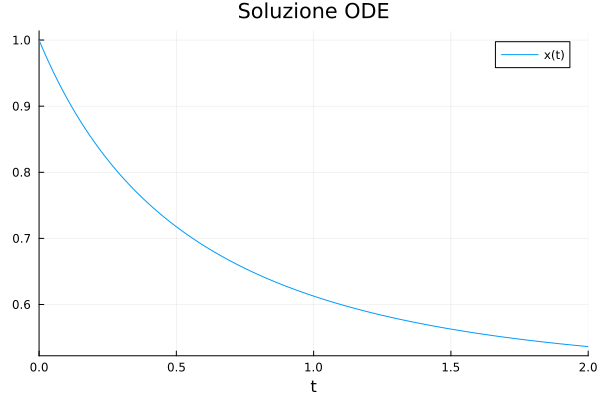

In [3]:
# Definire la funzione f
f(x, p, t) = -exp(-t) * x^2

# Definire la condizione iniziale e l'intervallo
x0 = 1.0           # condizione iniziale
tspan = (0.0, 2.0) # intervallo

# Definire il problema
prob = ODEProblem(f, x0, tspan)

# Risolvere il problema
sol = solve(prob) # La variabile sol contiene l'approssimazione della soluzione

# Disegnare la soluzione
plot(sol, idxs=(0 , 1), label="x(t)", title="Soluzione ODE")

L'output di `solve` e' un array di tipo `struct` che in particolare contiene il vettore `t` dei punti in cui e' stato discretizzato l'intervallo e l'array `u` della soluzione, dove `u[i]` corrisponde alla soluzione al tempo `t[i]`. Il comando `idxs` permette di selezionare le colonne della soluzione che vogliamo disegnare. L'indice `0` corrisponde al tempo, l'indice `1` alla prima componente della soluzione, l'indice `2` alla seconda componente, e cosi' via. La descrizione completa si ottiene mediante il comando `?ODESolution`.

In [7]:
?ODESolution

search: ODESolution RODESolution DESolution DAESolution ODEFunction



```julia
struct ODESolution{T, N, uType, uType2, DType, tType, rateType, discType, P, A, IType, S, AC<:Union{Nothing, Vector{Int64}}, R, O, V} <: SciMLBase.AbstractODESolution{T, N, uType}
```

Representation of the solution to an ordinary differential equation defined by an ODEProblem.

## DESolution Interface

For more information on interacting with `DESolution` types, check out the Solution Handling page of the DifferentialEquations.jl documentation.

[https://docs.sciml.ai/DiffEqDocs/stable/basics/solution/](https://docs.sciml.ai/DiffEqDocs/stable/basics/solution/)

## Fields

  * `u`: the representation of the ODE solution. Given as an array of solutions, where `u[i]` corresponds to the solution at time `t[i]`. It is recommended in most cases one does not access `sol.u` directly and instead use the array interface described in the Solution Handling page of the DifferentialEquations.jl documentation.
  * `t`: the time points corresponding to the saved values of the ODE solution.
  * `prob`: the original ODEProblem that was solved.
  * `alg`: the algorithm type used by the solver.
  * `stats`: statistics of the solver, such as the number of function evaluations required, number of Jacobians computed, and more.
  * `retcode`: the return code from the solver. Used to determine whether the solver solved successfully, whether it terminated early due to a user-defined callback, or whether it exited due to an error. For more details, see [the return code documentation](https://docs.sciml.ai/SciMLBase/stable/interfaces/Solutions/#retcodes).


Nel caso multidimensionale le operazioni da eseguire sono analoghe.

**Esercizio 2 (svolto).** Risolvere il problema
$$
\left\{\begin{array}{l}
x_1'(t)=x_2(t)\\
x_2'(t)=-x_1(t)\\
x_1(0)=1\\
x_2(0)=0
\end{array}\right.
$$
con $t\in [0,2\pi]$, successivamente tracciare le soluzioni e le orbite $(x_1(t), x_2(t))$.

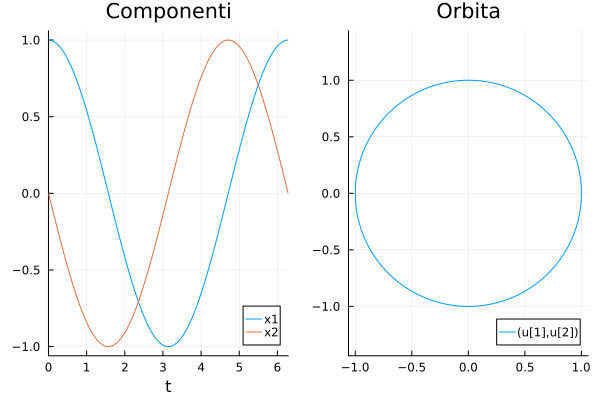

In [4]:
# Definiamo la funzione
# Il ! dopo il nome significa che modifico una variabile di input
function system_f!(du, u, p, t)
    du[1] = u[2]
    du[2] = -u[1]
end

# Intervallo e valore iniziale
u0 = [1.0, 0.0]
tspan = (0.0, 2*pi)

# Problema e soluzione
prob = ODEProblem(system_f!, u0, tspan)
sol = solve(prob)

# Plot delle componenti
p1 = plot(sol, labels=["x1" "x2"], title="Componenti")

# Plot delle orbite
p2 = plot(sol, idxs=(1, 2), title="Orbita", aspect_ratio=:equal)

# Disegna i grafici a fianco
plot(p1, p2, layout=(1, 2))

**Esercizio 3**. Risolvere l'equazione del pendolo semplice
$$
x''(t)=-\sin x(t)
$$
con condizioni iniziali $x(0)=1$ e $x'(0)=0$, nell'intervallo $t\in[0,20]$. Disegnare il grafico di $x(t)$ e di $x'(t)$.

 **Suggerimento.** Si tratta di un'equazione del secondo ordine, che si puo' trasformare in un sistema di ordine 1 ponendo $u_1(t)=x(t)$ e $u_2(t)=x'(t)$, dunque ottenendo
$$
\left\{\begin{array}{l}
u_1'(t)=u_2(t)\\
u_2'(t)=-\sin u_1(t)\\
u_1(0)=1\\
u_2(0)=0
\end{array}\right.
$$

In [ ]:
# inserire qui il codice

Vediamo un esempio in cui la funzione the definisce l'equazione differenziale dipende da alcuni parametri.

**Esercizio 4 (svolto)**. Immaginate una contenitore di liquido caldo in un ambiente freddo. La velocità con cui il liquido si raffredda è proporzionale alla differenza tra la sua temperatura e quella dell'ambiente. L'equazione della temperatura del liquido è
$$T'(t) = -k(T(t) - T_{amb})$$
dove $k$ è la costante di raffreddamento e $T_{amb}$ è la temperatura della stanza.

Supponendo che la temperatura iniziale sia 85 gradi, quella ambiente 20 gradi, che $k=0.1$, si tracci il grafico della temperatura del liquido nell'intervallo di tempo $[0, 30]$.


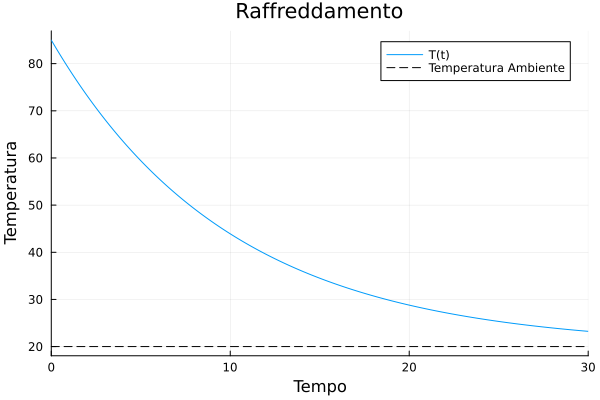

In [10]:
# Definizione della funzione f(u, p, t)
# u: temperatura attuale
# p: parametri [k, Tamb]
# t: tempo
function raffreddamento(u, p, t)
    k, Tamb = p
    return -k * (u - Tamb)
end

# Ingredienti del problema
T0 = 85.0              # Temperatura iniziale del liquido (85°C)
tspan = (0.0, 30.0)    # Osserviamo per 30 minuti
parametri = [0.1, 20.0] # k = 0.1, Tamb = 20.0°C

# Costruzione del problema e soluzione
prob = ODEProblem(raffreddamento, T0, tspan, parametri)
sol = solve(prob)

# Grafico
plot(sol,
     title="Raffreddamento",
     xlabel="Tempo",
     ylabel="Temperatura",
     label="T(t)")

# Aggiungiamo una linea per la temperatura ambiente per confronto
hline!([20.0], label="Temperatura Ambiente", linestyle=:dash, color=:black)

---
# 2. Oscillatore armonico

Consideriamo il sistema costituito da un punto materiale $P$ di massa $m$ attaccato ad una molla di costante elastica $h>0$.

Se si sposta $P$ dalla posizione di equilibrio, su $P$ agisce la forza elastica della molla, che per la legge di Hooke \`e proporzionale all'allungamento della molla stessa. Si lascia poi andare $P$. Per la seconda legge della dinamica, la posizione $x(t)$ di $P$ al tempo $t$ soddisfa l'equazione
$$
mx''(t)=-hx(t).
$$

Si possono elaborare modelli piu' complessi che tengono conto anche di altre forze. Per esempio, se $P$ si muove in un mezzo viscoso, su di esso agisce una forza smorzante proporzionale alla velocita'. Oppure possiamo supporre che $P$ sia soggetto all'azione di una forza esterna $\varphi(t)$, dipendente o meno dal tempo. Nella sua forma piu' completa, il modello e'
$$
mx''(t)=-hx(t)-kx'(t)+\varphi(t),\qquad h, k>0.
$$

**Esercizio 5.** Si consideri l'equazione dell'oscillatore armonico con i parametri fissati come segue:
*  Oscillatore libero non smorzato: $m=1$, $h=10$, $k=0$, $\varphi=0$; come condizioni iniziali si scelga $x(0)=1$, $x'(0)=0$; il tempo di osservazione sia $[0,60]$
*  Oscillatore libero sottosmorzato: $m=1$, $h=10$, $k=0.5$, $\varphi=0$; condizioni iniziali e tempo di osservazione come nel caso precedente;
*  Oscillatore libero sovrasmorzato: stessi parametri del caso precedente, tranne il valore di $k$ che diventa $k=10$;
*  Oscillatore forzato smorzato: $m=2$, $h=10$, $k=0.75$, $\varphi=25$; come condizioni iniziali si scelga $x(0)=2$, $x'(0)=0$; tempo di osservazione come nei casi precedenti.

Si disegnino sullo stesso grafico, per ciascun caso, le funzioni posizione $x(t)$ e velocita' $x'(t)$.

**Suggerimento**. Trasformare il problema in un problema di ordine 1. Nella `function oscillatore!(du, u, p, t)` che definisce il problema differenziale, per assegnare i parametri `m, h, k, phi` alla variabile `p` , si puo' usare l'istruzione
`m, h, k, phi = p`.

In [ ]:
# Inserire qui il codice

**Esercizio 6.**
Nel problema dell'esercizio precedente, consideriamo il caso in cui $\varphi(t)=\alpha\cos(\omega t)$, con $\alpha,\omega>0$ e supponiamo che non vi sia attrito, cioe' $k=0$. Supponiamo $m=1$, $h=4$ e $\alpha=1$ e prendiamo come condizioni iniziali $x(0)=0$ e $x'(0)=1$.

L'obiettivo di questo esercizio \`e simulare il fenomeno dei *battimenti* e della *risonanza*.

Per ciascuno dei tre casi seguenti, risolva l'equazione dell'oscillatore armonico e tracci in un'unica figura la soluzione calcolata (in blu) e il grafico di $\varphi(t)$ (in rosso):
$$
\omega=1.5,\qquad \omega=1.8,\qquad \omega=\sqrt{h}=2.
$$
Che cosa osservate?


In [ ]:
# inserire qui il codice


---
# 3. Attrattore di Lorenz

Nello studio dei sistemi caotici rivestono un ruolo di primo piano i modelli che descrivono le traiettorie dei punti di un fluido sotto determinate sollecitazioni (calore, differenze di pressione, ecc.), come ad esempio nei vortici che si formano per i moti convettivi nell'atmosfera. Queste traiettorie evolvono talvolta verso insiemi di tipo particolare, detti attrattori.

Un caso molto studiato \`e l'*attrattore di Lorenz*
https://en.wikipedia.org/wiki/Lorenz_system, descritto dalle equazioni
$$
\left\{\begin{array}{l}
x_1'(t)=\sigma(x_2(t)-x_1(t))\\
x_2'(t)=rx_1(t)-x_2(t)-x_1(t)x_3(t)\\
x_3'(t)=x_1(t)x_2(t)-bx_3(t)\\
\end{array}\right.
$$
dove $\sigma$, $r$ e $b$ sono parametri opportuni.

**Esercizio 7.**
Calcolare la soluzione numerica del modello di Lorenz nel caso $\sigma=10$, $r=28$, $b=8/3$ a partire dalle seguenti condizioni iniziali:
*  $x_1(0)=x_2(0)=x_3(0)=1$,
*  $x_1(0)=x_2(0)=x_3(0)=1+10^{-5}$,

per un tempo $t_{\rm max}$ adeguato. Realizzare separatamente i grafici delle componenti $(t,x_1)$, $(t,x_2)$, $(t,x_3)$ e delle traiettorie nello spazio $(x_1,x_2,x_3)$. In ciascun grafico si traccino in blu i dati relativi al primo caso e in rosso i dati relativi al secondo caso.

I dati iniziali sono vicini; che cosa si osserva riguardo al comportamento della soluzione al crescere di $t_{\rm max}$?

**Suggerimento.** Se la variabile `sol` rappresenta la soluzione, per disegnare in blu la traiettoria in $\mathbb{R}^3$ si usa il comando `plot(sol, idxs=(1, 2, 3), lc=:blue, label="Traiettoria" )`



In [ ]:
# inserire qui il codice